# Kaili Golden ; DATA 581
# Midterm Assessment

## 1. Audience-Focused Executive Summary

The purpose of this analysis is to explore whether body mass differs across the three penguin species in the Palmer penguins dataset: Adelie, Chinstrap, and Gentoo penguins. Differences in body mass may provide researchers with insight into how these species vary in their physical characteristics. It may also reflect differences in their habitats, feeding behaviors, and other adaptations such as flipper length and bill length. </br>

The results showed differences in body mass across the three species. Gentoo penguins were noticeably heavier than both Adelie and Chinstrap penguins, which makes them the largest of the three species in the provided dataset. Adelie and Chinstrap species had more similar body masses, although the Chinstrap penguins appeared to be slightly heavier on average. Some overlap in body masses between the three species was identified. However, the overall patterns in the findings indicate that there is an association between species and body mass. </br>

The above findings suggest that body mass is an important physical characteristic that distinguishes the three penguin species. Particularly, the larger difference between the Gentoo species and the Adelie and Chinstrap species might suggest that body mass can be a useful indicator when comparing species and/or populations. That said, body mass alone should not distinguish the penguin species, as the findings revealed that individuals from different species still fell within similar weight ranges. </br>

The findings also highlight the importance of considering other characteristics as well as within-species differences when exploring penguin characteristics. Characteristics such as flipper length, bill length, and bill depth can be combined with body mass to provide a more complete picture of how the species differ. This in turn may improve species identification and understanding. Other factors such as sex, age, diet, or environmental conditions could also provide insight into penguin biology and penguin population health. </br>

Ultimately, the analysis revealed that body mass varied noticeably across the three penguin species, with Gentoo penguins being considerably heavier than Adelie and Chinstrap penguins. This highlights the biological characteristics of the three species and may encourage exploration of not only across-species analysis when handling and interpreting penguin data, but also species-specific analysis.


In [25]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## 2. EDA and Visualizations

In [6]:
penguins = sns.load_dataset("penguins")
print(penguins.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


In [36]:
# data cleaning
print(penguins[["species", "body_mass_g"]].isnull().sum())

# drop na rows
penguins_cleaned = penguins.dropna(subset=["body_mass_g"])

# compare original vs. cleaned dataset sizes
print(f"Original dataset size: {len(penguins)}")
print(f"Cleaned dataset size: {len(penguins_cleaned)}")

species        0
body_mass_g    2
dtype: int64
Original dataset size: 344
Cleaned dataset size: 342


In [49]:
# summary stats
p_mean = penguins_cleaned.groupby("species")["body_mass_g"].mean()
print(f"Mean: \n{p_mean}")

p_median = penguins_cleaned.groupby("species")["body_mass_g"].median()
print(f"\n Median: \n{p_median}")

p_var = penguins_cleaned.groupby("species")["body_mass_g"].var()
print(f"\n Variance: \n{p_var}")

p_std = penguins_cleaned.groupby("species")["body_mass_g"].std()
print(f"\n Standard deviation: \n{p_std}")


Mean: 
species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

 Median: 
species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64

 Variance: 
species
Adelie       210282.891832
Chinstrap    147713.454785
Gentoo       254133.180061
Name: body_mass_g, dtype: float64

 Standard deviation: 
species
Adelie       458.566126
Chinstrap    384.335081
Gentoo       504.116237
Name: body_mass_g, dtype: float64


### The 4 Visualizations

Text(0, 0.5, 'Mean Body Mass (g)')

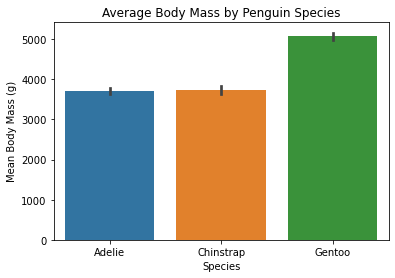

In [51]:
# 1. categorical comparison

ax = sns.barplot(
    data=penguins_cleaned,
    x="species",
    y="body_mass_g"
)

plt.title("Average Body Mass by Penguin Species")
plt.xlabel("Species")
plt.ylabel("Mean Body Mass (g)")

#### **Interpretation**
Of the dataset's three species the Gentoo species appears to have the highest mean body mass (in grams). Comparatively, the chinstrap species appears to a slightly higher mean body mass than the Adelie species, though their mean body mass is similar.

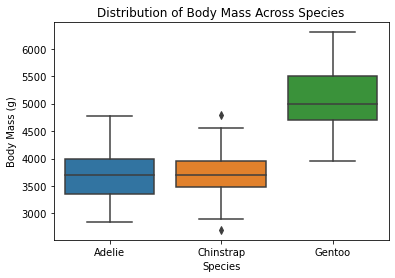

In [28]:
# 2. Distribution chart

sns.boxplot(
    data=penguins_cleaned,
    x="species",
    y="body_mass_g"
)

plt.title("Distribution of Body Mass Across Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()


#### **Interpretation**
The distribution range of body mass appears approximately the same across the three species, with the Gentoo species having a greater number of individuals falling within its lower and  upper quartile. Furthermore, the Gentoo species appears to be generally heavier than the Adelie and Chinstrap species. This is indicated by the Gentoo quartile range falling within a higher body mass range than the quartiles for the other two species.

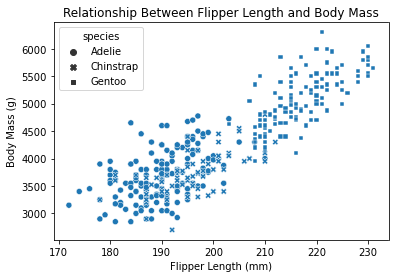

In [40]:
# 3. Relationship chart

sns.scatterplot(
    data=penguins_cleaned,
    x="flipper_length_mm",
    y="body_mass_g",
    style="species"
)

plt.title("Relationship Between Flipper Length and Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend(title="species")
plt.show()

#### **Interpretation**
There appears to be a positive correlation between flipper length (in millimeters) and body mass (in grams); as flipper length increases, so does body mass. This makes sense in terms of weight: the longer the flipper length the heavier the penguin. </br>

The longer flipper lengths and higher body mass also appear to belong primarily to Gentoo penguins, as indicated by the concentration of the square data points in the middle and upper half of the plot's right region.

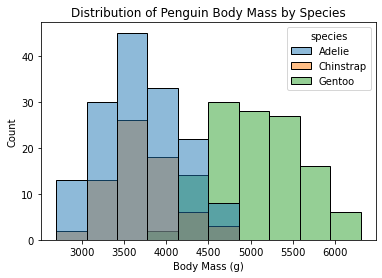

In [47]:
# 4. Choice visualization (histogram)

sns.histplot(
    data=penguins_cleaned,
    x="body_mass_g",
    hue="species",
    bins=10
)
plt.title("Distribution of Penguin Body Mass by Species")
plt.xlabel("Body Mass (g)")
plt.ylabel("Count")
plt.show()

#### **Interpretation**
It appears that the Gentoo species is heavier than the Adelie and Chinstrap species, with a greater number of its individuals falling in the middle to upper range of the full body mass range. In contrast, the Adelie species appears to have most of its individuals in the lower to middle range of the full body mass range (of approximately 2500 to 6500 grams). The chinstrap species appears to fall around the middle to lower half of the full body mass range. This is consistent with its mean body mass being slightly higher but similar to the Adelie species.

## 3. Visualization Critique

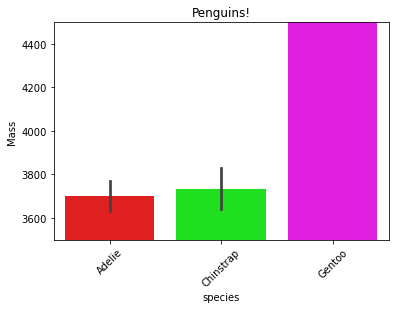

In [45]:
sns.barplot(
    data=penguins_cleaned,
    x="species",
    y="body_mass_g",
    palette=["red","lime","magenta"]
)

plt.title("Penguins!")
plt.ylabel("Mass")

plt.ylim(3500,4500)
plt.xticks(rotation=45)
plt.show()

#### **What makes this visual misleading?**
The above barplot is misleading for a number of reasons and violates several visualization principles/best practices, in which violation of these practices hurt clarity, honesty, and presentation impact. For one, the plot's bright, distracting colors are unappealing and unnecessary for presentation purposes. Secondly, both the x-axis and y-axis labels are vague; we do not know in what units the mass is, let alone what kind of mass is being quantified. A third misdirection lies in there being a truncated y-axis: the differences in body mass between the three species appears larger than they truly are. Furthermore, the truncation completely cuts off the upper limit of the Gentoo species' body mass. This information should be visible within the plot's dimensions. Another misdirection could occur in the unnecessary rotation of the x-axis labels. Conventionally, the labels should be displayed parallel to the x-axis line. And finally, the title is vague. It should clearly describe what relationship the plot is capturing. </br>


Redesigning this visualization I would apply greyscale colors to the three bars. I would edit the y-axis title to be "Body Mass (g)" or "Body Mass (grams)". The x-axis labels would be rotated such that they're parallel to the x-axis line. I would also edit the y-axis range to include the upper limit of the Gentoo species' body mass, and have it such that the tick marks are shown by the 1000s. Finally, I would rename the plot title to something like "Body Mass by Penguin Species", which would better capture the relationship in the plot. </br>

## 4. Technical Report

#### **Introduction**

Penguin species differ in their physical characteristics. However, knowing which characteristics best distinguish species is not always immediately clear. Exploring and understanding differences in body mass provides one approach to making this clearer, where in exploring these differences researchers may be able to better describe the penguin species, uncover patterns in their biology, and gain insights into the adaptations of the different species to their specific environment.

#### **Dataset Description**

This Palmer Penguin dataset was loaded into Jupyter through Seaborn and consists of seven variables describing three different penguin species: Adelie, Chinstrap, and Gentoo penguins. Each individual (row) is characterized by their species name, their sex (Male or Female), bill lenght (mm), bill depth (mm), flipper length (mm), body mass (g), and the name of the island which they inhabit.

#### **Methodology**

Data preparation and preprocessing involved first loading the dataset into Jupyter through the seaborn library. The dataset's two variables of interest, species and body mass, were then jointly searched for any NaNs or missing values. Given only two NaNs were found under the body mass column, these rows were then removed. Analysis then consisted of generating several visual plots to explore the relationship between species and body mass. These plots included a bar plot, a box plot, a scatter plot, and a histogram.

#### **Results (Main)**

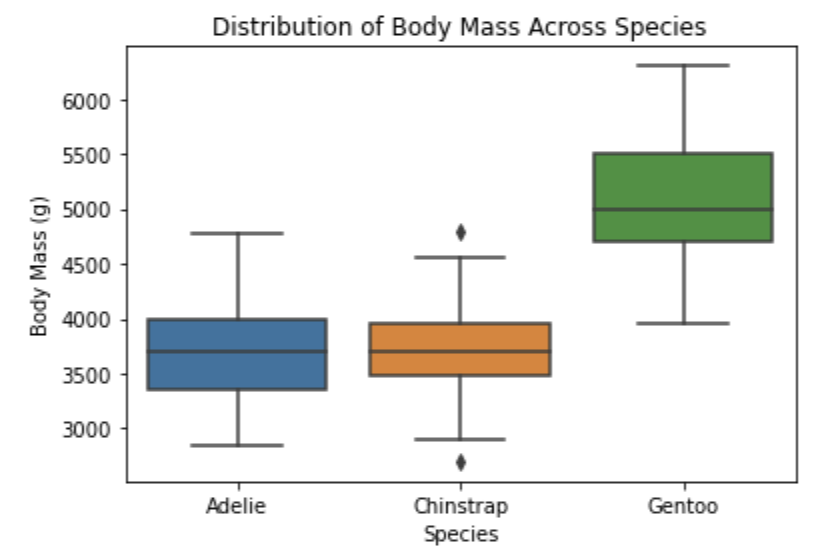

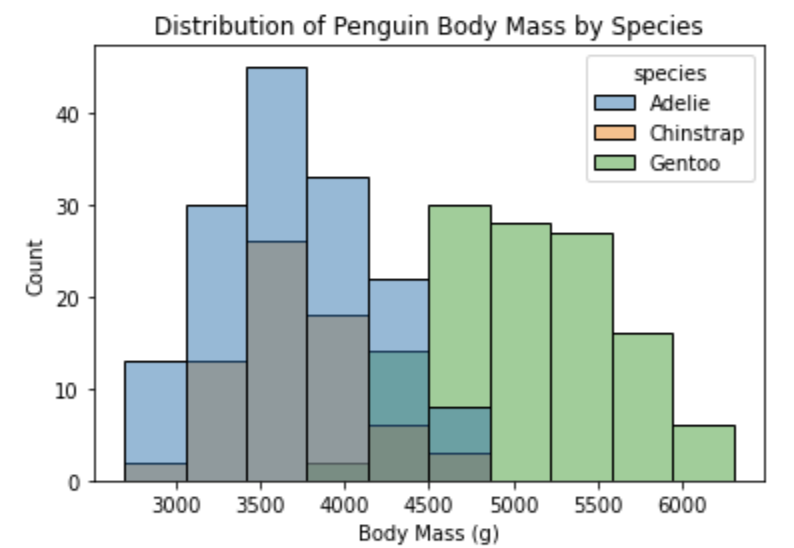

#### **Discussion**

The box plot (first visualization) demonstrates the distribution of body mass within each of the dataset's three penguin species. The lower and upper quartile for the Gentoo species falls within a considerably higher body mass range than the quartiles for both the Adelie and Chinstrap species. This indicates the Gentoo penguins are generally heavier than the Adelie and Chinstrap penguins. </br>

The histrogram demonstrates the distribution of body mass across the dataset's three species. In general, the Gentoo individuals have a higher body mass than those of the Adelie and Chinstrap species. This is illustrated by the green bars lying primarily in the middle to rightmost region of the plot. On the other hand, the number of Adelie and Chinstrap indviduals fall primarily in the middle to lower half of the plot, as indicated by the green bars and grey color where the Adelie individuals' weights overlap with those of the Chinstrap individuals. Both species' individuals tend to have lighter weights than those of the Gentoo species. </br>

#### **Conclusion**

From these findings there is strong support for there being an association between species and body mass, or weight, with the Gentoo species being heavier than both the Adelie and Chinstrap species. Though this was revealed through the analysis, it is still advisable to combine and further explore the relationships between body mass and other characteristic variables in the dataset. The relationship between different variables, such as bill length and bill depth, should also be investigated. Together, this in-depth EDA could provide more insight into the penguin species' differences and their characterization.

## 5. Ethical Reflection

**Q: How can data visualizations unintentionally mislead audiences, and what responsibilities do analysts have when presenting results?** </br>

**A:** Data visualizations can unintentionally mislead audiences through violation of best practices such as using improper axes scaling, which can exaggerate or truncate differences in trends. Violation of best practices can lead audiences to misinterpret what trend is being wrongfully presented. Or suppose an improper chart is selected to model a relationship between two variables. For example, suppose we selected a scatter plot to model the relationship between the penguin species and body mass. This would be incorrect, as one of the variables (penguin species) is categorical; a scatter plot is used to model the relationship between two numerical variables. Other violations that can mislead audiences include failing to provide context, or presenting visuals such that they're noisy, distracting, and/or cluttered. A lack of context could mean providing a vague visualization title, and/or vague or no axis titles. Context should be provided, and this involves providing information on where the data was taken from. Furthermore, cherry-picked data often leads to false or fabricated narratives, which in turn misleads audiences. The false narrative usually paints an incomplete and/or inaccurate picture of the data being presented. </br>

When presenting results analysts have responsibilities to not violate these practices that otherwise risk misleading audiences and encouraging misinterpretations. Knowing where the data one is working with came from, and how it was gathered, is one starting point. It continues to be the analyst's duty to handle, process, and understand the data such that any downstream effects are not biased, falsely created, or inaccurate to what the data itself is showing. Taking extra care and caution to provide accurate, clean visualizations is one way in which analysts take responsibility when presenting results. And understanding the data upon which the visualizations are built is a necessary precondition.

## 6. Challenge Questions

**Q1: Which visualization best communicates your strongest finding and why?** </br>
The box plot appears to best communicate the finding that Gentoo penguins outweigh Adelie and Chinstrap penguins. In this visualization the distribution of weight is most evidently different for the Gentoo species than for the other two species. A larger number of individuals fall within its lower and upper quartile range, and the quartile itself sits within a higher body mass range than the quartiles for the other two species. The body mass difference in the Gentoo species is most apparent in this plot, versus the body mass differences demonstrated in the bar plot and the histogram.

**Q2: What additional data would improve your conclusions?** </br>
In my analysis other variables in the dataset such as bill length, bill depth, island origin, or sex, were not included. As discussed, including these variables and combining them would likely provide more insight into how the three penguin species differ in their characteristics. Furthermore, only basic EDA was performed. More in-depth EDA would include exploring multivariate relationships to examine how body mass interacts with the other variables. This was done between flipper length and body mass (*Visualization 3. Relationship Chart*), but it should be extended to other variable pairs such as body mass vs. bill length, and body mass vs. bill depth. Species-specific relationships should also be explored. For example, whether flipper length correlates equally across all three species could be interesting to investigate. Exploring relationships involving island effects and sex effects would also be worthwhile.
